## About this notebook — `ridge_valley.ipynb`

**Purpose:** Extract clean ridge and valley maps from a fingerprint image using a precise
polygon ROI selector. Produces a print-ready valley image (black valleys on white) for
fake-fingerprint mold fabrication. Supports both automatic and manual ROI definition.

| | |
|---|---|
| **Input** | Scanned or photo fingerprint (any quality) |
| **Output** | `ridge_map.png` · `valley_map.png` · `rv_vis.png` · **`valley_print.png`** (send to printer) |
| **Pipeline** | ipywidgets sliders + custom polygon ROI editor (click vertices, drag to adjust) |
| **Best for** | Valley extraction for fake fingerprints; situations requiring precise manual ROI |

### Methods used
**ROI:** `variance_roi` · `threshold` · `foreground` masks · manual polygon with vertex editing  
**Processing:** `CLAHE` · `median smoothing` · `adaptive / Gaussian / Sauvola binarization` ·
`morphology (close / open / fill holes)` · ridge/valley separation · print-ready inversion

### Reactive parameter bars
Parameter colour bars turn **grey** when a setting has no effect for the currently
selected binarization method (e.g. Blur is grey for Sauvola; Thresh is grey for adaptive).

### Re-use parameters for a second finger
After tuning, use the *"Process another finger"* cells at the bottom to apply the
exact same widget values to a new image without re-tuning.

---

### Notebook comparison

| | Notebook | Input | Output | Pipeline | Best for |
|---|:---|:---|:---|:---|:---|
| | scanning | Live scanner | Captured images | Buttons | Acquire fingerprints from hardware |
| | scanned_small_pipeline | Scanned image | Skeleton + minutiae | Widget sliders | Quick processing, sensible defaults |
| | scanned_full_pipeline | Scanned image | Skeleton + minutiae | Widget sliders + toggles | Full parameter control, scanned FP |
| | photo_finger | Photo (dark background) | Skeleton + minutiae | Widget sliders | Full photo pipeline (ImageJ-based) |
| ▶ | **ridge_valley** | Photo or scanned | Valley print map | Widgets + polygon ROI | Valley extraction with manual ROI |
| | photo_valley_pipeline | Photo | Valley print map | Static comparisons | Experiment with photo → valley methods |
| | algorithms_explorer | Any | Side-by-side comparisons | Static comparisons | Learn and compare all available algorithms |


In [51]:
import sys, importlib
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: /home/x232886/PycharmProjects/PV080_biometrics


In [52]:
import inspect
from typing import Any, Dict, Tuple

import cv2
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path as MplPath
from matplotlib.widgets import PolygonSelector

import fingerprints.interactive as ip
import fingerprints.utils as fputils

try:
    import fingerprints.enhancement as enh
except Exception:
    enh = None

try:
    import fingerprints.mask as fpmask
except Exception:
    fpmask = None

try:
    import fingerprints.binarization as fpbin
except Exception:
    fpbin = None

try:
    import fingerprints.morphology as fpmorph
except Exception:
    fpmorph = None

for _mod in [ip, fputils, enh, fpmask, fpbin, fpmorph]:
    if _mod is not None:
        importlib.reload(_mod)

ensure_odd = fputils.ensure_odd
normalize_gray = fputils.normalize_gray

print('All modules loaded.')

All modules loaded.


## Load image

In [53]:
# ── CONFIGURE HERE ────────────────────────────────────────────────────────────
UCO = '232886'   # your UCO number
N   = 1          # photo version (1, 2, 3 ...)
# ──────────────────────────────────────────────────────────────────────────────

Loaded: index_232886_1.jpeg  shape=(2016, 1512)  dtype=uint8


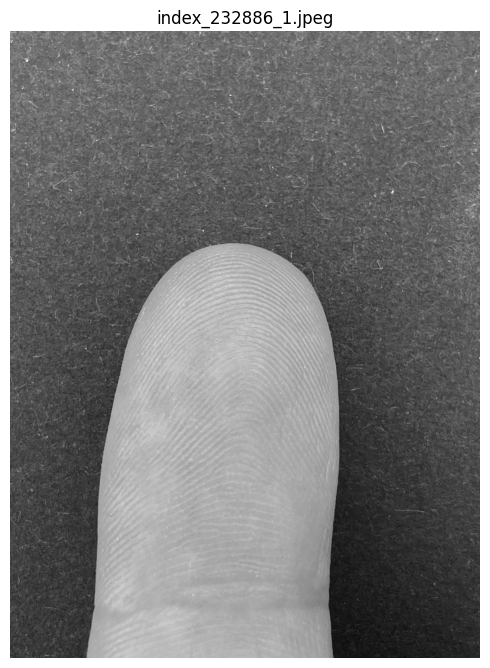

In [54]:
import re

_errors = []
if not str(UCO).isdigit():
    _errors.append(f'  UCO "{UCO}" must be digits only')
if not isinstance(N, int) or N < 1:
    _errors.append(f'  N "{N}" must be a positive integer')

if _errors:
    print('Config errors — fix the config cell above and re-run:')
    for e in _errors: print(e)
    IMAGE_PATH = None
else:
    PHOTOS_DIR = PROJECT_ROOT / 'data' / 'photos' / 'real'

    # match any {letters}_{UCO}_{N}.ext — finger name is inferred from filename
    _pattern = re.compile(rf'^[a-zA-Z]+_{re.escape(str(UCO))}_{N}\.(jpeg|jpg|png|bmp|tiff?)$', re.IGNORECASE)
    _matches = sorted(p for p in PHOTOS_DIR.iterdir() if _pattern.match(p.name))

    if not _matches:
        print(f'No file found in: {PHOTOS_DIR}')
        print(f'Expected e.g.: index_{UCO}_{N}.jpeg  or  thumb_{UCO}_{N}.jpeg')
        IMAGE_PATH = None
    else:
        IMAGE_PATH = _matches[0]
        img = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise RuntimeError(f'Failed to load: {IMAGE_PATH}')
        print(f'Loaded: {IMAGE_PATH.name}  shape={img.shape}  dtype={img.dtype}')

        fig_prev, ax_prev = plt.subplots(figsize=(5, 7))
        ax_prev.imshow(img, cmap='gray')
        ax_prev.set_title(IMAGE_PATH.name)
        ax_prev.axis('off')
        plt.tight_layout()
        plt.show()

## ROI / Mask selection

Choose **Auto** to compute a mask from image statistics (adjustable parameters), or **Manual** to draw a polygon directly on the image.

The three panels below always update live: **Original | Mask | Masked image**.

In [56]:
## --- AUTO MASK ---  run this cell to use automatic ROI detection

_COL_ON  = '#28a745'
_COL_OFF = '#dc3545'

_METHOD_PARAMS = {
    'variance_roi': {'var_block', 'erode_k', 'close_iter', 'dilate_iter', 'close_k', 'min_area'},
    'threshold':    {'thresh', 'invert', 'close_k', 'min_area'},
    'foreground':   {'blur_k', 'fg_block', 'C', 'close_k', 'min_area'},
}
_COL_LEFT  = ['var_block', 'erode_k', 'close_iter', 'dilate_iter', 'thresh', 'invert']
_COL_RIGHT = ['blur_k', 'fg_block', 'C', 'close_k', 'min_area']


def _png_bytes(arr):
    import io
    from PIL import Image as PilImage
    buf = io.BytesIO()
    PilImage.fromarray(arr.astype(np.uint8)).save(buf, format='PNG')
    return buf.getvalue()


class AutoMaskWidget:
    def __init__(self, img: np.ndarray, display_w: int = 200):
        self.img = img
        h, w = img.shape[:2]
        self._dw = display_w
        self._dh = int(display_w * h / w)
        self.mask = np.ones((h, w), dtype=np.uint8) * 255

        W, D = '195px', '65px'
        def _sl(desc, kind, value, lo, hi, step=1):
            cls = widgets.IntSlider if kind == 'int' else widgets.FloatSlider
            return cls(value=value, min=lo, max=hi, step=step, description=desc,
                       continuous_update=False,
                       layout=widgets.Layout(width=W), style={'description_width': D})
        def _cb(desc, val):
            return widgets.Checkbox(value=val, description=desc, indent=False,
                                    layout=widgets.Layout(width=W))

        self._method = widgets.Dropdown(
            options=['variance_roi', 'threshold', 'foreground'], value='variance_roi',
            description='Method', layout=widgets.Layout(width='405px'),
            style={'description_width': D},
        )
        self._sliders = {
            'var_block':   _sl('Block',    'int', 31,  4,  64, 2),
            'erode_k':     _sl('Erode K',  'int',  7,  1,  31, 2),
            'close_iter':  _sl('CloseIt',  'int',  4,  1,  10),
            'dilate_iter': _sl('DilateIt', 'int',  1,  0,   5),
            'thresh':      _sl('Thresh',   'int', 35,  0, 120),
            'invert':      _cb('Invert', False),
            'blur_k':      _sl('Blur K',  'int',  9,  1, 21, 2),
            'fg_block':    _sl('Block',   'int', 31,  3, 81, 2),
            'C':           _sl('C',       'int',  7, -10, 20),
            'close_k':     _sl('Close K', 'int', 25,  1, 61, 2),
            'min_area':    _sl('Min area','int', 1000, 0, 10000, 100),
        }

        def _bar(color):
            return widgets.HTML(
                f"<div style='width:4px;height:22px;background:{color};"
                f"border-radius:2px;margin-right:4px'></div>")
        self._markers = {k: _bar(_COL_OFF) for k in self._sliders}

        def _row(key):
            return widgets.HBox([self._markers[key], self._sliders[key]],
                                layout=widgets.Layout(align_items='center'))
        col_left  = widgets.VBox([_row(k) for k in _COL_LEFT])
        col_right = widgets.VBox([_row(k) for k in _COL_RIGHT])

        def _panel(label):
            wi = widgets.Image(format='png',
                layout=widgets.Layout(width=f'{display_w}px', height=f'{self._dh}px',
                    border='1px solid #ccc', margin='0 4px 0 0'))
            return wi, widgets.VBox([widgets.HTML(f'<small><b>{label}</b></small>'), wi])

        self._w_orig,   _p_orig   = _panel('Original')
        self._w_mask,   _p_mask   = _panel('Mask')
        self._w_masked, _p_masked = _panel('Masked')
        self._status = widgets.Label(value='Ready.')

        self._confirm_btn = widgets.Button(description='Use This Mask',
            button_style='primary', layout=widgets.Layout(width='150px', height='36px'))
        self._confirm_status = widgets.HTML('')
        self._confirm_btn.on_click(self._on_confirm)

        self.widget = widgets.VBox([
            self._method,
            widgets.HBox([col_left, col_right]),
            widgets.HBox([_p_orig, _p_mask, _p_masked]),
            self._status,
            widgets.HBox([self._confirm_btn, self._confirm_status],
                layout=widgets.Layout(align_items='center', margin='8px 0 0 0')),
        ])

        self._method.observe(self._on_method_change, names='value')
        for _w in self._sliders.values():
            _w.observe(self._compute, names='value')
        self._update_markers()
        self._refresh_orig()
        self._compute()

    def _update_markers(self):
        active = _METHOD_PARAMS.get(self._method.value, set())
        on  = lambda c: f"<div style='width:4px;height:22px;background:{c};border-radius:2px;margin-right:4px'></div>"
        for key, marker in self._markers.items():
            marker.value = on(_COL_ON if key in active else _COL_OFF)

    def _on_method_change(self, _=None):
        self._update_markers()
        self._compute()

    def _compute(self, _=None):
        self._status.value = 'Computing...'
        try:
            s = self._sliders
            m = self._method.value
            if m == 'threshold' and fpmask is not None:
                mask = fpmask.mask_from_black_background(
                    self.img, thresh=s['thresh'].value, invert=s['invert'].value,
                    open_k=0, close_k=s['close_k'].value, min_area=s['min_area'].value)
            elif m == 'foreground' and fpmask is not None:
                mask = fpmask.build_foreground_mask(
                    self.img, blur_k=s['blur_k'].value, block=s['fg_block'].value,
                    C=s['C'].value, open_k=0,
                    close_k=s['close_k'].value, min_area=s['min_area'].value)
            elif m == 'variance_roi' and fpmask is not None:
                mask = fpmask.compute_fingerprint_roi(
                    self.img, block=s['var_block'].value, close_k=s['close_k'].value,
                    erode_k=s['erode_k'].value, close_iter=s['close_iter'].value,
                    dilate_iter=s['dilate_iter'].value, min_area=s['min_area'].value)
            else:
                _, mask = cv2.threshold(normalize_gray(self.img), 35, 255, cv2.THRESH_BINARY)
            self.mask = mask
            self._render_panels()
        except Exception as e:
            self._status.value = f'Error: {e}'

    def _render_panels(self):
        from PIL import Image as PilImage
        img8 = normalize_gray(self.img)
        pil_m = PilImage.fromarray(self.mask).resize((self._dw, self._dh), PilImage.NEAREST)
        self._w_mask.value = _png_bytes(np.array(pil_m))
        masked = img8.copy(); masked[self.mask == 0] = 0
        pil_i = PilImage.fromarray(masked).resize((self._dw, self._dh), PilImage.LANCZOS)
        self._w_masked.value = _png_bytes(np.array(pil_i))
        n = int((self.mask > 0).sum())
        self._status.value = f'{n:,} px inside mask ({100*n/self.mask.size:.1f}%)'

    def _refresh_orig(self):
        from PIL import Image as PilImage
        img8 = normalize_gray(self.img)
        pil = PilImage.fromarray(img8).resize((self._dw, self._dh), PilImage.LANCZOS)
        self._w_orig.value = _png_bytes(np.array(pil))

    def _on_confirm(self, _=None):
        globals()['polygon_mask'] = self.mask
        try:
            pipeline.update_mask(self.mask)
        except NameError:
            pass
        n = int((self.mask > 0).sum())
        self._confirm_status.value = (
            f"<span style='color:{_COL_ON};font-weight:bold;margin-left:8px'>"
            f"Confirmed -- {n:,} px sent to pipeline</span>")

    def get_mask(self):
        return self.mask


auto_widget = AutoMaskWidget(img)
display(auto_widget.widget)


## MANUAL mask selection - if needed
Uncomment and execute following cell to use manual mask only if above cell is not sufficient for ROI selection.

In [57]:
# ## --- MANUAL MASK ---  run this cell to draw a polygon ROI
# # Click vertices on the image, press Done when finished.
# # You can click existing vertices (yellow) to move them after closing.
#
# _HIT_R = 12
#
#
# class ManualPolyWidget:
#     def __init__(self, img: np.ndarray, display_w: int = 200):
#         from PIL import Image as PilImage
#         from ipycanvas import MultiCanvas, hold_canvas as _hc
#
#         self.img = img
#         h, w = img.shape[:2]
#         self._dw = display_w
#         self._dh = int(display_w * h / w)
#         self.mask = np.ones((h, w), dtype=np.uint8) * 255
#         self._hc = _hc
#
#         max_cw, max_ch = display_w * 2, display_w * 3
#         self._scale = min(max_cw / w, max_ch / h)
#         self._cw = int(w * self._scale)
#         self._ch = int(h * self._scale)
#
#         img8 = normalize_gray(img)
#         import io as _io
#         pil = PilImage.fromarray(img8, 'L').convert('RGB').resize(
#             (self._cw, self._ch), PilImage.LANCZOS)
#         buf = _io.BytesIO()
#         pil.save(buf, format='PNG')
#         self._bg_iw = widgets.Image(value=buf.getvalue(), format='png')
#
#         self._verts_img    = []   # image-space (x, y)
#         self._verts_canvas = []   # canvas-space (x, y)
#         self._done   = False
#         self._sel    = None       # selected vertex index
#
#         self._canvas = MultiCanvas(2, width=self._cw, height=self._ch)
#         self._canvas.layout.border = '1px solid #aaa'
#         self._canvas.layout.cursor = 'crosshair'
#         self._canvas.on_mouse_down(self._on_click)
#
#         self._label = widgets.Label(value='Switch to this cell, then click the image to add vertices.')
#         btn_done  = widgets.Button(description='Done',  button_style='success',
#                                    layout=widgets.Layout(width='80px'))
#         btn_reset = widgets.Button(description='Reset', button_style='warning',
#                                    layout=widgets.Layout(width='80px'))
#         btn_done.on_click(self._on_done)
#         btn_reset.on_click(self._on_reset)
#
#         self._preview = widgets.Image(format='png',
#             layout=widgets.Layout(width=f'{display_w}px', height=f'{self._dh}px',
#                 border='1px solid #ccc'))
#         self._status = widgets.Label(value='No mask yet.')
#
#         self._confirm_btn = widgets.Button(description='Use This Mask',
#             button_style='primary', layout=widgets.Layout(width='150px', height='36px'))
#         self._confirm_status = widgets.HTML('')
#         self._confirm_btn.on_click(self._on_confirm)
#
#         self.widget = widgets.VBox([
#             self._label,
#             widgets.HBox([
#                 widgets.VBox([self._canvas, widgets.HBox([btn_done, btn_reset])]),
#                 widgets.VBox([
#                     widgets.HTML('<small><b>Mask preview</b></small>'),
#                     self._preview,
#                     self._status,
#                     widgets.HBox([self._confirm_btn, self._confirm_status],
#                         layout=widgets.Layout(align_items='center')),
#                 ]),
#             ], layout=widgets.Layout(align_items='flex-start', gap='12px')),
#         ])
#
#     def _draw_bg(self):
#         self._canvas[0].draw_image(self._bg_iw, 0, 0, self._cw, self._ch)
#
#     def _repaint(self):
#         layer = self._canvas[1]
#         with self._hc(layer):
#             layer.clear()
#             verts = self._verts_canvas
#             if len(verts) >= 2:
#                 pts = [(int(x), int(y)) for x, y in verts]
#                 pts_loop = pts + [pts[0]] if self._done else pts
#                 layer.stroke_style = 'cyan'
#                 layer.line_width = 2
#                 layer.begin_path()
#                 layer.move_to(*pts_loop[0])
#                 for px, py in pts_loop[1:]:
#                     layer.line_to(px, py)
#                 layer.stroke()
#             for i, (x, y) in enumerate(verts):
#                 r = 8 if i == self._sel else 5
#                 layer.fill_style = 'orange' if i == self._sel else 'yellow'
#                 layer.begin_path()
#                 layer.arc(int(x), int(y), r, 0, 2 * np.pi)
#                 layer.fill()
#                 layer.stroke_style = 'black'
#                 layer.line_width = 1
#                 layer.stroke()
#
#     def _nearest(self, cx, cy):
#         best_i, best_d = None, float('inf')
#         for i, (vx, vy) in enumerate(self._verts_canvas):
#             d = ((cx - vx)**2 + (cy - vy)**2)**0.5
#             if d < _HIT_R and d < best_d:
#                 best_i, best_d = i, d
#         return best_i
#
#     def _on_click(self, x, y):
#         cx, cy = float(x), float(y)
#         if self._done:
#             if self._sel is None:
#                 hit = self._nearest(cx, cy)
#                 if hit is not None:
#                     self._sel = hit
#                     self._label.value = f'Vertex {hit} selected -- click to move it.'
#                     self._repaint()
#             else:
#                 idx = self._sel
#                 self._verts_canvas[idx] = (cx, cy)
#                 self._verts_img[idx] = (cx / self._scale, cy / self._scale)
#                 self._sel = None
#                 self._label.value = 'Vertex moved. Click another or confirm.'
#                 self._rasterize()
#                 self._repaint()
#             return
#         self._verts_canvas.append((cx, cy))
#         self._verts_img.append((cx / self._scale, cy / self._scale))
#         self._label.value = f'{len(self._verts_img)} vertices -- press Done to close.'
#         self._repaint()
#
#     def _rasterize(self):
#         if len(self._verts_img) < 3:
#             return
#         h, w = self.img.shape[:2]
#         xi, yi = np.meshgrid(np.arange(w), np.arange(h))
#         pts = np.vstack([xi.ravel(), yi.ravel()]).T
#         inside = MplPath(self._verts_img).contains_points(pts, radius=0.5)
#         self.mask = inside.reshape(h, w).astype(np.uint8) * 255
#         self._confirm_status.value = ''
#         self._update_preview()
#
#     def _update_preview(self):
#         from PIL import Image as PilImage
#         img8 = normalize_gray(self.img).copy()
#         img8[self.mask == 0] = 0
#         pil = PilImage.fromarray(img8).resize((self._dw, self._dh), PilImage.LANCZOS)
#         import io as _io; buf = _io.BytesIO()
#         pil.save(buf, format='PNG')
#         self._preview.value = buf.getvalue()
#         n = int((self.mask > 0).sum())
#         self._status.value = f'{n:,} px ({100*n/self.mask.size:.1f}%)'
#
#     def _on_done(self, _=None):
#         if len(self._verts_img) < 3:
#             self._label.value = 'Need at least 3 vertices!'
#             return
#         self._done = True
#         self._sel = None
#         self._rasterize()
#         self._label.value = (
#             f'Closed ({len(self._verts_img)} verts). '
#             f'Click a yellow vertex to move it, or confirm mask.')
#         self._repaint()
#
#     def _on_reset(self, _=None):
#         self._verts_img    = []
#         self._verts_canvas = []
#         self._done = False
#         self._sel  = None
#         self.mask  = np.ones(self.img.shape[:2], dtype=np.uint8) * 255
#         self._draw_bg()
#         self._canvas[1].clear()
#         self._label.value = 'Reset. Click to add vertices.'
#         self._confirm_status.value = ''
#         self._preview.value = b''
#         self._status.value = 'No mask yet.'
#
#     def _on_confirm(self, _=None):
#         globals()['polygon_mask'] = self.mask
#         try:
#             pipeline.update_mask(self.mask)
#         except NameError:
#             pass
#         n = int((self.mask > 0).sum())
#         self._confirm_status.value = (
#             f"<span style='color:#28a745;font-weight:bold;margin-left:8px'>"
#             f"Confirmed -- {n:,} px sent to pipeline</span>")
#
#     def get_mask(self):
#         return self.mask
#
#     def reset(self):
#         self._on_reset()
#
#
# poly_widget = ManualPolyWidget(img)
# display(poly_widget.widget)
# # Draw background AFTER display so canvas is in the DOM
# poly_widget._draw_bg()


## Step wrappers

In [58]:
def call_kwargs(func, /, **kwargs):
    """Call func with only the kwargs it accepts."""
    allowed = set(inspect.signature(func).parameters)
    return func(**{k: v for k, v in kwargs.items() if k in allowed})


def widget_from_spec(spec: Dict[str, Any]):
    kind = spec['kind']
    if kind == 'int':
        return widgets.IntSlider(
            value=spec['value'], min=spec['min'], max=spec['max'],
            step=spec.get('step', 1), description=spec['label'], continuous_update=False
        )
    if kind == 'float':
        return widgets.FloatSlider(
            value=spec['value'], min=spec['min'], max=spec['max'],
            step=spec.get('step', 0.1), description=spec['label'], continuous_update=False
        )
    if kind == 'bool':
        return widgets.Checkbox(value=spec['value'], description=spec['label'], indent=False)
    if kind == 'choice':
        return widgets.Dropdown(options=spec['options'], value=spec['value'], description=spec['label'])
    raise ValueError(f'Unknown kind: {kind}')


def wspec(specs):
    return {k: widget_from_spec(v) for k, v in specs.items()}


# -----------------------------------------------------------------------
# Step: crop image to mask bounding box and apply mask within the crop.
# -----------------------------------------------------------------------
def step_crop_to_mask(image, polygon_mask=None):
    if polygon_mask is None or not (polygon_mask > 0).any():
        return image, polygon_mask

    rows = np.any(polygon_mask > 0, axis=1)
    cols = np.any(polygon_mask > 0, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    img_crop  = image[rmin:rmax + 1, cmin:cmax + 1].copy()
    mask_crop = polygon_mask[rmin:rmax + 1, cmin:cmax + 1].copy()
    img_crop[mask_crop == 0] = 0
    return img_crop, mask_crop


# -----------------------------------------------------------------------
# Step: CLAHE
# -----------------------------------------------------------------------
def step_clahe(image, clip=2.0, tile=8):
    img8 = normalize_gray(image)
    if enh is not None and hasattr(enh, 'apply_clahe'):
        return call_kwargs(enh.apply_clahe, img_gray=img8, clip=clip, tile=tile)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return clahe.apply(img8)


# -----------------------------------------------------------------------
# Step: Median smoothing (optional, 0 = off)
# -----------------------------------------------------------------------
def step_median(image, ksize=0):
    if ksize <= 0:
        return image
    k = ensure_odd(ksize, 1)
    return cv2.medianBlur(normalize_gray(image), k)


# -----------------------------------------------------------------------
# Step: Binarization
#
# Active parameters per method:
#   adaptive_gaussian_blurred  block  C  blur
#   adaptive_gaussian          block  C
#   adaptive / adaptive_mean   block  C
#   sauvola                    block          (block → window_size)
#   otsu                       —
#   fixed                                        thresh
# -----------------------------------------------------------------------
_BIN_ACTIVE_PARAMS = {
    'adaptive_gaussian_blurred': {'block', 'C', 'blur'},
    'adaptive_gaussian':         {'block', 'C'},
    'adaptive':                  {'block', 'C'},
    'adaptive_mean':             {'block', 'C'},
    'sauvola':                   {'block'},
    'otsu':                      set(),
    'fixed':                     {'thresh'},
}

def step_binarize(image, method='adaptive_gaussian_blurred', block=21, C=2, blur=3, thresh=127):
    img8 = normalize_gray(image)

    if fpbin is not None:
        fn_map = {
            'fixed':                     'fixed_binarize',
            'otsu':                      'otsu_binarize',
            'adaptive':                  'adaptive_binarize',
            'adaptive_mean':             'adaptive_mean_binarize',
            'adaptive_gaussian':         'adaptive_gaussian_binarize',
            'adaptive_gaussian_blurred': 'adaptive_gaussian_binarize_blurred',
            'sauvola':                   'sauvola_binarize',
        }
        fn_name = fn_map.get(method)
        fn = getattr(fpbin, fn_name, None) if fn_name else None
        if fn is not None:
            # window_size=block lets the Block slider work for sauvola
            return call_kwargs(
                fn, img_gray=img8, gray=img8, img=img8,
                thresh=thresh, block_size=block, window_size=block,
                C=C, blur_ksize=blur, invert=True
            )

    if method == 'fixed':
        _, out = cv2.threshold(img8, thresh, 255, cv2.THRESH_BINARY)
        return out
    if method == 'otsu':
        _, out = cv2.threshold(img8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return out
    b = ensure_odd(block, 3)
    src = cv2.GaussianBlur(img8, (ensure_odd(blur, 1),) * 2, 0)
    return cv2.adaptiveThreshold(src, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, b, C)


# -----------------------------------------------------------------------
# Step: Morphology cleanup
# -----------------------------------------------------------------------
def step_morphology(binary, polygon_mask=None, close_k=3, open_k=3, fill_holes=True, remove_small=0):
    out = (binary > 0).astype(np.uint8) * 255
    if close_k > 0:
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ensure_odd(close_k, 1),) * 2)
        out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, ker)
    if open_k > 0:
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ensure_odd(open_k, 1),) * 2)
        out = cv2.morphologyEx(out, cv2.MORPH_OPEN, ker)
    if fill_holes:
        h, w = out.shape
        flood = (255 - out).copy()
        mask_ff = np.zeros((h + 2, w + 2), np.uint8)
        cv2.floodFill(flood, mask_ff, (0, 0), 128)
        holes = (flood == 255).astype(np.uint8)
        out = np.maximum(out, holes * 255).astype(np.uint8)
    if remove_small > 0:
        n, labels, stats, _ = cv2.connectedComponentsWithStats((out > 0).astype(np.uint8), 8)
        clean = np.zeros_like(out)
        for i in range(1, n):
            if stats[i, cv2.CC_STAT_AREA] >= remove_small:
                clean[labels == i] = 255
        out = clean
    if polygon_mask is not None:
        out[polygon_mask == 0] = 0
    return out


# -----------------------------------------------------------------------
# Step: Ridge / Valley map
# -----------------------------------------------------------------------
def step_ridge_valley(binary, polygon_mask=None):
    mask = (polygon_mask > 0) if polygon_mask is not None else np.ones(binary.shape, bool)
    ridge  = ((binary > 0) & mask).astype(np.uint8) * 255
    valley = ((binary == 0) & mask).astype(np.uint8) * 255

    h, w = binary.shape

    vis = np.full((h, w, 3), 200, dtype=np.uint8)
    vis[mask] = 255
    vis[(ridge > 0)] = (220, 60, 60)
    vis[(valley > 0)] = (60, 100, 220)

    # Print-ready: white background, black valleys within ROI.
    valley_print = np.full((h, w), 255, dtype=np.uint8)
    valley_print[(binary == 0) & mask] = 0

    return ridge, valley, vis, valley_print


def _step_ridge_valley_wrapper(binary, polygon_mask=None):
    return step_ridge_valley(binary, polygon_mask)


print('Wrappers defined.')


Wrappers defined.


## Build & run interactive pipeline

In [59]:
# ---- Inject polygon mask into pipeline context after reset ------------
class RidgeValleyPipeline(ip.InteractivePipeline):
    """Pipeline that seeds `polygon_mask` into context on each reset."""

    def __init__(self, *args, polygon_mask: np.ndarray = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.polygon_mask = polygon_mask

    def run_from(self, start_index: int = 0):
        if self.initial_image is None:
            return
        self.context.reset(self.initial_image)
        self.context['polygon_mask'] = self.polygon_mask
        for i, step in enumerate(self.steps):
            ok = step.run(self.context)
            if not ok:
                for j in range(i + 1, len(self.steps)):
                    self.steps[j].status_label.value = 'Blocked by previous error'
                break

    def run(self):
        self.run_from(0)

    def update_mask(self, new_mask: np.ndarray):
        self.polygon_mask = new_mask
        self.run()

    def apply_to_image(self, new_image: np.ndarray, new_mask: np.ndarray = None):
        """Run pipeline on a new image, reusing all current widget parameter values."""
        self.initial_image = new_image
        if new_mask is not None:
            self.polygon_mask = new_mask
        self.run()


# ---- Bar HTML helper (also used by mask widget above) ----------------
def _bar_html(color):
    return (
        f"<div style='width:4px;min-width:4px;height:22px;"
        f"background:{color};border-radius:2px;margin-right:4px'></div>"
    )

def _param_bar(color):
    return widgets.HTML(_bar_html(color))

def _param_row(bar_widget, w):
    return widgets.HBox([bar_widget, w], layout=widgets.Layout(align_items='center'))


# ---- Step specs -------------------------------------------------------
_STEPS = [
    {
        'name': 'Crop to mask',
        'func': step_crop_to_mask,
        'input_map': {'image': 'image', 'polygon_mask': 'polygon_mask'},
        'output_keys': ['image', 'polygon_mask'],
        'display_key': 'image',
        'enabled': True,
        'params': {},
    },
    {
        'name': 'CLAHE',
        'func': step_clahe,
        'input_map': {'image': 'image'},
        'output_keys': ['image'],
        'enabled': True,
        'params': wspec({
            'clip': {'kind': 'float', 'value': 2.0, 'min': 0.5, 'max': 8.0, 'step': 0.1, 'label': 'Clip'},
            'tile': {'kind': 'int',   'value': 8,   'min': 2,   'max': 32,  'step': 1,   'label': 'Tile'},
        }),
    },
    {
        'name': 'Median smoothing',
        'func': step_median,
        'input_map': {'image': 'image'},
        'output_keys': ['image'],
        'enabled': False,
        'params': wspec({
            'ksize': {'kind': 'int', 'value': 0, 'min': 0, 'max': 14, 'step': 2, 'label': 'K (0=off)'},
        }),
    },
    {
        'name': 'Binarization',
        'func': step_binarize,
        'input_map': {'image': 'image'},
        'output_keys': ['binary'],
        'display_key': 'binary',
        'enabled': True,
        'params': wspec({
            'method': {'kind': 'choice', 'value': 'adaptive_gaussian_blurred',
                       'options': ['adaptive_gaussian_blurred', 'adaptive_gaussian', 'adaptive',
                                   'adaptive_mean', 'sauvola', 'otsu', 'fixed'],
                       'label': 'Method'},
            'block':  {'kind': 'int',   'value': 21,  'min': 3,   'max': 101, 'step': 2,   'label': 'Block'},
            'C':      {'kind': 'int',   'value': 2,   'min': -20, 'max': 20,  'step': 1,   'label': 'C'},
            'blur':   {'kind': 'int',   'value': 3,   'min': 1,   'max': 21,  'step': 2,   'label': 'Blur'},
            'thresh': {'kind': 'int',   'value': 127, 'min': 0,   'max': 255, 'step': 1,   'label': 'Thresh'},
        }),
        # which params are active for each method value
        'param_visibility': {'method': _BIN_ACTIVE_PARAMS},
    },
    {
        'name': 'Morphology',
        'func': step_morphology,
        'input_map': {'binary': 'binary', 'polygon_mask': 'polygon_mask'},
        'output_keys': ['binary'],
        'display_key': 'binary',
        'enabled': True,
        'params': wspec({
            'close_k':      {'kind': 'int',  'value': 1,    'min': 0, 'max': 21,   'step': 2, 'label': 'Close'},
            'open_k':       {'kind': 'int',  'value': 1,    'min': 0, 'max': 21,   'step': 2, 'label': 'Open'},
            'fill_holes':   {'kind': 'bool', 'value': False,                                    'label': 'Fill holes'},
            'remove_small': {'kind': 'int',  'value': 0,    'min': 0, 'max': 2000, 'step': 10,'label': 'Min area'},
        }),
    },
    {
        'name': 'Ridge / Valley map',
        'func': _step_ridge_valley_wrapper,
        'input_map': {'binary': 'binary', 'polygon_mask': 'polygon_mask'},
        'output_keys': ['ridge_map', 'valley_map', 'rv_vis', 'valley_print'],
        'display_key': 'rv_vis',
        'enabled': True,
        'params': {},
    },
]


# ---- Instantiate Step objects -----------------------------------------
def _make_step(spec):
    input_map        = spec.get('input_map', {})
    display_key      = spec.get('display_key')
    param_visibility = spec.get('param_visibility', {})

    class MappedStep(ip.Step):
        def get_ui(self, layout_mode: str = 'fixed', image_scale: float = 1.0):
            size = int(300 * image_scale)
            self.image_widget.width  = f'{size}px'
            self.image_widget.height = f'{size}px'

            if not self.enabled and layout_mode == 'dynamic':
                return None

            # Build param rows; keep a ref to each bar widget for reactive colouring
            _bars = {}   # param_name → HTML bar widget
            param_rows = [self.checkbox]
            for pname, w in self.params.items():
                if isinstance(w, widgets.Widget):
                    bar = _param_bar(_COL_ON)
                    _bars[pname] = bar
                    param_rows.append(_param_row(bar, w))

            # Wire up reactive bar colours driven by a "selector" param
            for selector_name, visibility_map in param_visibility.items():
                selector_w = self.params.get(selector_name)
                if not isinstance(selector_w, widgets.Widget):
                    continue

                def _refresh_bars(change, _vm=visibility_map, _b=_bars, _sn=selector_name):
                    active = _vm.get(change['new'], set())
                    for pn, bar in _b.items():
                        if pn == _sn:
                            continue  # the selector itself is always active
                        bar.value = _bar_html(_COL_ON if pn in active else _COL_OFF)

                selector_w.observe(_refresh_bars, names='value')
                # Set initial state immediately
                active = visibility_map.get(selector_w.value, set())
                for pn, bar in _bars.items():
                    if pn != selector_name:
                        bar.value = _bar_html(_COL_ON if pn in active else _COL_OFF)

            self.controls_container = widgets.VBox(
                param_rows, layout=widgets.Layout(width='100%')
            )

            if not self.enabled and layout_mode == 'fixed':
                self.controls_container.layout.display = 'none'
                placeholder = widgets.HTML(
                    f"<div style='width:{size}px;height:{size}px;background:#eee;"
                    f"display:flex;align-items:center;justify-content:center;"
                    f"color:#aaa'>Skipped<br>({self.name})</div>"
                )
                return widgets.VBox(
                    [widgets.Label(self.name), placeholder, self.checkbox],
                    layout=widgets.Layout(border='1px solid #ddd', margin='5px', padding='5px'),
                )

            self.controls_container.layout.display = 'flex'
            return widgets.VBox(
                [widgets.Label(self.name, style={'font_weight': 'bold'}),
                 self.image_widget,
                 self.controls_container,
                 self.status_label],
                layout=widgets.Layout(
                    border='1px solid #888', margin='5px', padding='5px',
                    width=f'{size + 20}px',
                ),
            )

        def run(self, context):
            if not self.enabled:
                self.status_label.value = 'Skipped'
                return True
            kwargs = {}
            for arg_name, ctx_key in input_map.items():
                val = context.get(ctx_key)
                if val is None and 'mask' not in arg_name:
                    self.status_label.value = f'Missing ctx key: {ctx_key}'
                    return False
                kwargs[arg_name] = val
            for pname, wobj in self.params.items():
                import ipywidgets as _w
                kwargs[pname] = wobj.value if isinstance(wobj, _w.Widget) else wobj
            try:
                import time as _t
                t0 = _t.time()
                result = self.func(**kwargs)
                dt = _t.time() - t0
                self.status_label.value = f'{dt*1000:.0f} ms'
                if len(self.output_keys) == 1:
                    context[self.output_keys[0]] = result
                    primary = result
                else:
                    if not isinstance(result, tuple):
                        context[self.output_keys[0]] = result
                        primary = result
                    else:
                        for i, k in enumerate(self.output_keys):
                            if i < len(result):
                                context[k] = result[i]
                        primary = result[0]
                disp = context.get(display_key) if display_key else primary
                if isinstance(disp, np.ndarray):
                    self.image_widget.value = ip._array_to_bytes(disp)
                return True
            except Exception as exc:
                self.status_label.value = f'Error: {exc}'
                return False

    return MappedStep(
        name=spec['name'],
        func=spec['func'],
        input_keys=list(spec.get('input_map', {}).values()),
        output_keys=spec['output_keys'],
        params=spec.get('params', {}),
        enabled=spec.get('enabled', True),
    )


steps = [_make_step(s) for s in _STEPS]

pipeline = RidgeValleyPipeline(
    steps=steps,
    initial_image=img,
    polygon_mask=polygon_mask,
)

display(pipeline.display())


## Scale calibration

Click **two points** on the processed image whose real-world distance you know, enter that distance in mm and the target print DPI, then press **Apply**.
All output images are rescaled in-place inside the pipeline context so `valley_print.png` will print at the correct physical size.

In [60]:
class ScaleCalibrationWidget:
    """
    Fingerprint scale calibration with real-size mm mesh.
    Drag the slider until the fingerprint matches your real finger on screen,
    or use two-point calibration for precise sizing.
    """

    _RESCALE_KEYS = ["binary", "ridge_map", "valley_map", "rv_vis", "valley_print"]
    _SCREEN_PX_MM = 1920 / 518  # 3.70 px/mm  (1920×1200 screen, 518 mm wide)
    _GRID_MM_W  = 60
    _GRID_MM_H  = 55

    def __init__(self, context, display_w=100):
        from ipycanvas import MultiCanvas, hold_canvas as _hc
        from PIL import Image as PilImage
        import io as _io

        self._PilImage  = PilImage
        self._io        = _io
        self._hc        = _hc
        self.context    = context
        self.points     = []
        self._pts_canvas = []
        self._scale_factor = None

        px_mm = self._SCREEN_PX_MM
        self._px_mm = px_mm
        self._gw = int(self._GRID_MM_W * px_mm)
        self._gh = int(self._GRID_MM_H * px_mm)

        img = next((context.get(k) for k in ("valley_map", "binary", "image")
                    if context.get(k) is not None), None)
        self._img = img
        h, w = img.shape[:2]
        self._img_scale = min(display_w * 2 / w, display_w * 3 / h)
        self._cw = int(w * self._img_scale)
        self._ch = int(h * self._img_scale)

        img8 = normalize_gray(img)
        pil_bg = PilImage.fromarray(img8, "L").convert("RGB").resize(
            (self._cw, self._ch), PilImage.LANCZOS)
        buf = _io.BytesIO(); pil_bg.save(buf, format="PNG")
        self._bg_iw = widgets.Image(value=buf.getvalue(), format="png")

        self._click_canvas = MultiCanvas(2, width=self._cw, height=self._ch)
        self._click_canvas.layout.border = "1px solid #aaa"
        self._click_canvas.layout.cursor = "crosshair"
        self._click_canvas.on_mouse_down(self._on_click)

        self._mesh_canvas = MultiCanvas(2, width=self._gw, height=self._gh)
        self._mesh_canvas.layout.border = "1px solid #888"

        self._slider = widgets.FloatSlider(
            value=18.0, min=8.0, max=28.0, step=0.5,
            description="Width (mm):",
            continuous_update=True,
            layout=widgets.Layout(width=f"{self._gw}px"),
            style={"description_width": "90px"})
        self._slider.observe(self._on_slider, names="value")

        self._dpi_txt = widgets.FloatSlider(
            value=600.0, min=100.0, max=1200.0, step=0.5,
            description="DPI:",
            continuous_update=False,
            layout=widgets.Layout(width="5cm"),
            style={"description_width": "50px"})
        self._mm_txt  = widgets.FloatText(value=10.0, description="Dist (mm):",
            layout=widgets.Layout(width="160px"))
        self._apply_btn = widgets.Button(description="Apply", button_style="success",
            layout=widgets.Layout(width="80px"))
        self._reset_btn = widgets.Button(description="Reset", button_style="warning",
            layout=widgets.Layout(width="80px"))
        self._size_apply_btn = widgets.Button(description="Apply size", button_style="success",
            layout=widgets.Layout(width="90px"))
        self._size_result = widgets.HTML(value="")
        self._click_label = widgets.HTML(
            value="Click two calibration points on the image.",
            layout=widgets.Layout(width=f"{self._cw}px",
                                  overflow="hidden", white_space="normal"))
        self._result = widgets.HTML(value="")

        self._apply_btn.on_click(self._on_apply)
        self._reset_btn.on_click(self._on_reset)
        self._size_apply_btn.on_click(self._on_size_apply)

        left_col = widgets.VBox([
            widgets.HTML("<b>Calibration points</b>"),
            self._click_label,
            self._click_canvas,
            widgets.VBox([self._mm_txt, self._dpi_txt],
                layout=widgets.Layout(gap="6px", margin="6px 0 2px 0")),
            widgets.HBox([self._apply_btn, self._reset_btn],
                layout=widgets.Layout(gap="6px")),
            self._result,
        ], layout=widgets.Layout(width=f"{self._cw + 16}px"))

        box_w = f"{self._gw + 12}px"

        mesh_box = widgets.VBox([
            widgets.HTML("<b>Real size</b>"),
            widgets.HTML("<small>Hold your finger on the screen — adjust width until it matches</small>"),
            self._mesh_canvas,
        ], layout=widgets.Layout(
            width=box_w,
            border="1px solid #ddd", padding="4px"))

        slider_box = widgets.VBox([
            widgets.HTML("<b>Finger width</b>"),
            self._slider,
            widgets.HBox([self._size_apply_btn, self._size_result],
                layout=widgets.Layout(gap="8px", align_items="center", margin="4px 0 0 0")),
        ], layout=widgets.Layout(
            width=box_w,
            border="1px solid #ddd", padding="4px", margin="8px 0 0 0"))

        right_col = widgets.VBox([
            mesh_box,
            slider_box,
        ], layout=widgets.Layout(margin="0 0 0 32px", width=box_w))

        self.widget = widgets.HBox(
            [left_col, right_col],
            layout=widgets.Layout(align_items="flex-start"))

    def _make_grid_pil(self):
        px = self._px_mm
        gw, gh = self._gw, self._gh
        img = self._PilImage.new("RGB", (gw, gh), "white")
        from PIL import ImageDraw
        draw = ImageDraw.Draw(img)
        for mm in range(0, self._GRID_MM_W + 1):
            x = int(mm * px)
            major = mm % 5 == 0
            color = "#888" if major else "#e0e0e0"
            width = 1 if major else 1
            draw.line([(x, 0), (x, gh)], fill=color, width=width)
            if major and mm > 0:
                draw.text((x + 2, 2), f"{mm}", fill="#666")
        for mm in range(0, self._GRID_MM_H + 1):
            y = int(mm * px)
            major = mm % 5 == 0
            color = "#888" if major else "#e0e0e0"
            draw.line([(0, y), (gw, y)], fill=color, width=width)
            if major and mm > 0:
                draw.text((2, y + 2), f"{mm}", fill="#666")
        return img

    def _draw_grid(self):
        import io as _io2
        grid_pil = self._make_grid_pil()
        buf = _io2.BytesIO(); grid_pil.save(buf, format="PNG")
        iw = widgets.Image(value=buf.getvalue(), format="png")
        self._mesh_canvas[0].draw_image(iw, 0, 0, self._gw, self._gh)
        self._grid_pil = grid_pil

    def _update_overlay(self, width_mm):
        import io as _io2
        arr = next((self.context.get(k) for k in ("valley_map", "binary")
                    if self.context.get(k) is not None), None)
        if not isinstance(arr, np.ndarray):
            return
        sw = max(1, int(width_mm * self._px_mm))
        ih, iw_arr = arr.shape[:2]
        sh = max(1, int(sw * ih / iw_arr))
        finger_pil = self._PilImage.fromarray(normalize_gray(arr), "L").convert("RGBA")
        finger_pil = finger_pil.resize((sw, sh), self._PilImage.LANCZOS)
        combined = self._grid_pil.copy().convert("RGBA")
        combined.paste(finger_pil, (0, 0), finger_pil)
        combined_rgb = combined.convert("RGB")
        buf = _io2.BytesIO(); combined_rgb.save(buf, format="PNG")
        iw = widgets.Image(value=buf.getvalue(), format="png")
        layer = self._mesh_canvas[1]
        with self._hc(layer):
            layer.clear()
            layer.draw_image(iw, 0, 0, self._gw, self._gh)

    def _draw_bg(self):
        self._click_canvas[0].draw_image(self._bg_iw, 0, 0, self._cw, self._ch)
        self._draw_grid()
        self._update_overlay(self._slider.value)

    def _repaint_points(self):
        layer = self._click_canvas[1]
        with self._hc(layer):
            layer.clear()
            for i, (cx, cy) in enumerate(self._pts_canvas):
                layer.stroke_style = "red"
                layer.line_width = 4
                layer.begin_path(); layer.move_to(cx-14, cy); layer.line_to(cx+14, cy); layer.stroke()
                layer.begin_path(); layer.move_to(cx, cy-14); layer.line_to(cx, cy+14); layer.stroke()
                layer.fill_style = "red"
                layer.font = "bold 14px sans-serif"
                layer.fill_text(str(i+1), cx+12, cy-4)
            if len(self._pts_canvas) == 2:
                x0, y0 = self._pts_canvas[0]
                x1, y1 = self._pts_canvas[1]
                layer.stroke_style = "rgba(255,80,80,0.9)"
                layer.line_width = 3
                layer.set_line_dash([6, 4])
                layer.begin_path(); layer.move_to(x0, y0); layer.line_to(x1, y1); layer.stroke()
                layer.set_line_dash([])

    def _on_click(self, x, y):
        if len(self.points) >= 2:
            return
        cx, cy = float(x), float(y)
        self.points.append((cx / self._img_scale, cy / self._img_scale))
        self._pts_canvas.append((cx, cy))
        self._repaint_points()
        if len(self.points) == 2:
            x0, y0 = self.points[0]
            x1, y1 = self.points[1]
            d_px = np.hypot(x1-x0, y1-y0)
            self._click_label.value = f"2 points — {d_px:.1f} px. Set DPI &amp; mm, press Apply."
        else:
            self._click_label.value = "Point 1 set. Click point 2."

    def _on_slider(self, change):
        if hasattr(self, "_grid_pil"):
            self._update_overlay(change["new"])

    def _on_reset(self, _=None):
        self.points.clear()
        self._pts_canvas.clear()
        self._scale_factor = None
        self._click_canvas[1].clear()
        self._click_label.value = "Reset — click two calibration points."
        self._result.value = ""

    def _on_size_apply(self, _=None):
        """Apply scale derived from the finger-width slider + DPI."""
        width_mm = self._slider.value
        dpi = self._dpi_txt.value
        if dpi <= 0:
            self._size_result.value = "<span style='color:red'>DPI must be &gt; 0</span>"
            return
        orig_h, orig_w = self._img.shape[:2]
        # scale factor: how many image pixels correspond to 1 output pixel at target DPI
        # finger width in px at target DPI = width_mm / 25.4 * dpi
        target_w_px = width_mm / 25.4 * dpi
        self._scale_factor = target_w_px / orig_w
        for key in self._RESCALE_KEYS:
            arr = self.context.get(key)
            if not isinstance(arr, np.ndarray):
                continue
            new_w = max(1, round(arr.shape[1] * self._scale_factor))
            new_h = max(1, round(arr.shape[0] * self._scale_factor))
            interp = cv2.INTER_AREA if self._scale_factor < 1 else cv2.INTER_LANCZOS4
            self.context[key] = cv2.resize(arr, (new_w, new_h), interpolation=interp)
        phys_h = orig_h / orig_w * width_mm
        self._size_result.value = (
            f"<span style='color:#28a745;font-weight:bold'>"
            f"{width_mm:.1f}×{phys_h:.1f} mm</span>")

    def _on_apply(self, _=None):
        if len(self.points) < 2:
            self._click_label.value = "Please click two points first."
            return
        dpi, d_mm = self._dpi_txt.value, self._mm_txt.value
        if dpi <= 0 or d_mm <= 0:
            self._click_label.value = "DPI and real distance must be &gt; 0."
            return
        x0, y0 = self.points[0]
        x1, y1 = self.points[1]
        d_px = np.hypot(x1-x0, y1-y0)
        self._scale_factor = (dpi / 25.4) / (d_px / d_mm)
        for key in self._RESCALE_KEYS:
            arr = self.context.get(key)
            if not isinstance(arr, np.ndarray):
                continue
            new_w = max(1, round(arr.shape[1] * self._scale_factor))
            new_h = max(1, round(arr.shape[0] * self._scale_factor))
            interp = cv2.INTER_AREA if self._scale_factor < 1 else cv2.INTER_LANCZOS4
            self.context[key] = cv2.resize(arr, (new_w, new_h), interpolation=interp)
        orig_h, orig_w = self._img.shape[:2]
        phys_w = round(orig_w * self._scale_factor) / dpi * 25.4
        phys_h = round(orig_h * self._scale_factor) / dpi * 25.4
        self._slider.value = max(self._slider.min, min(self._slider.max, phys_w))
        self._result.value = (
            f"<span style='color:#28a745;font-weight:bold'>"
            f"Applied — {phys_w:.1f}x{phys_h:.1f} mm"
            f"</span>")
        self._update_overlay(phys_w)

    def get_scale_factor(self):
        return self._scale_factor


scale_widget = ScaleCalibrationWidget(pipeline.context)
display(scale_widget.widget)
scale_widget._draw_bg()

## Save results

In [61]:
if IMAGE_PATH is None:
    print('No image loaded — set UCO / N in the config cell and re-run.')
else:
    stem = IMAGE_PATH.stem  # e.g. 'index_232886_1'

    OUT_DIR = IMAGE_PATH.parent / 'processed'
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    arr = pipeline.context.get('valley_print')
    if arr is None:
        print('valley_print not found in pipeline context — run the pipeline first.')
    else:
        out_path = OUT_DIR / f'{stem}_valleys_black.png'
        cv2.imwrite(str(out_path), arr)
        print(f'Saved → {out_path}')
        print('Black areas = valleys (ink) | White areas = ridges (no ink)')
        print(f'→ Send to printer: {out_path.name}')

Saved → /home/x232886/PycharmProjects/PV080_biometrics/data/photos/real/processed/index_232886_1_valleys_black.png
Black areas = valleys (ink) | White areas = ridges (no ink)
→ Send to printer: index_232886_1_valleys_black.png
